### <div style="background-color:blue; color:white; padding:10px;"> Import libraries </div>

In [24]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import scipy.sparse as sp
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score

### <div style="background-color:blue; color:white; padding:10px;"> Paths and parameters </div>

In [25]:
FEATURES_CSV = "../Features/Charades/00N38_features.csv"
LABELS_CSV = "../Labels/Charades/00N38_labels.csv"
GRAPH_PATH = "../Graph/Charades/00N38_transition_matrix.npz"

MODEL_PATH = "../Model/Charades/00N38_model.pt"
PREDICTIONS_CSV = "../Prediction/Charades/00N38_predictions.csv"
METRICS_CSV = "../Metrics/Charades/00N38_metrics.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LR = 3e-4
# ALPHA = 0.5  # label propagation coefficient

print("Device:", DEVICE)

Device: cuda


### <div style="background-color:blue; color:white; padding:10px;"> Load features and labels </div>

In [26]:
features_df = pd.read_csv(FEATURES_CSV)
labels_df = pd.read_csv(LABELS_CSV)
features = features_df.drop(columns=["frame_id"]).values.astype(np.float32)
labels = labels_df.drop(columns=["frame_id"]).values.astype(np.float32)
T, FEATURE_DIM = features.shape
_, NUM_CLASSES = labels.shape
print("Features:", features.shape)
print("Labels:", labels.shape)

Features: (588, 512)
Labels: (588, 37)


### <div style="background-color:blue; color:white; padding:10px;">Load transition matrix</div>

In [27]:
P_sparse = sp.load_npz(GRAPH_PATH)
P = P_sparse.toarray().astype(np.float32)
P_tensor = torch.from_numpy(P).to(DEVICE)
print("Transition matrix:", P_tensor.shape)

Transition matrix: torch.Size([588, 588])


### <div style="background-color:blue; color:white; padding:10px;">Convert data to torch tensors</div>

In [28]:
X = torch.from_numpy(features).float().to(DEVICE)
X = F.normalize(X, dim=1)
Y = torch.from_numpy(labels).float().to(DEVICE)

In [29]:
pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts
weights = neg_counts / (pos_counts + 1e-12)
weights = torch.from_numpy(weights).float().to(DEVICE)

In [30]:
print("X:", X.shape)
print("labels:", labels.shape)
print("P:", P_tensor.shape)

X: torch.Size([588, 512])
labels: (588, 37)
P: torch.Size([588, 588])


### <div style="background-color:blue; color:white; padding:10px;"> Define classifier </div>

In [31]:
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [32]:
model = Classifier(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights)

### <div style="background-color:blue; color:white; padding:10px;">Random Walk label propagation function</div>

In [33]:
def residual_random_walk(logits, P, alpha=0.5, steps=5):
    Y = torch.sigmoid(logits)
    confidence = torch.abs(Y - 0.5) * 2
    uncertainty = 1 - confidence
    for _ in range(steps):
        Y = Y + alpha * uncertainty * (torch.matmul(P, Y) - Y)
    return Y

### <div style="background-color:blue; color:white; padding:10px;"> Training loop </div>

In [34]:
EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    # Forward pass (FULL GRAPH)
    logits = model(X)                  # (T × C)
    pred = torch.sigmoid(logits)       # (T × C)
    loss_cls = criterion(logits, Y)
    loss_graph = ((pred - torch.matmul(P_tensor, pred))**2).mean()
    loss_temporal = ((pred[1:] - pred[:-1])**2).mean()
    loss = loss_cls + 0.5 * loss_graph + 0.2 * loss_temporal
    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    print(f"Epoch {epoch+1}, Total Loss: {loss.item():.4f}")

Epoch 1, Total Loss: 0.7590
Epoch 2, Total Loss: 0.7215
Epoch 3, Total Loss: 0.6865
Epoch 4, Total Loss: 0.6600
Epoch 5, Total Loss: 0.6385
Epoch 6, Total Loss: 0.6173
Epoch 7, Total Loss: 0.6021
Epoch 8, Total Loss: 0.5840
Epoch 9, Total Loss: 0.5659
Epoch 10, Total Loss: 0.5527
Epoch 11, Total Loss: 0.5389
Epoch 12, Total Loss: 0.5311
Epoch 13, Total Loss: 0.5244
Epoch 14, Total Loss: 0.5171
Epoch 15, Total Loss: 0.5095
Epoch 16, Total Loss: 0.5021
Epoch 17, Total Loss: 0.4949
Epoch 18, Total Loss: 0.4900
Epoch 19, Total Loss: 0.4838
Epoch 20, Total Loss: 0.4757
Epoch 21, Total Loss: 0.4715
Epoch 22, Total Loss: 0.4694
Epoch 23, Total Loss: 0.4648
Epoch 24, Total Loss: 0.4618
Epoch 25, Total Loss: 0.4564
Epoch 26, Total Loss: 0.4559
Epoch 27, Total Loss: 0.4508
Epoch 28, Total Loss: 0.4499
Epoch 29, Total Loss: 0.4457
Epoch 30, Total Loss: 0.4429
Epoch 31, Total Loss: 0.4392
Epoch 32, Total Loss: 0.4404
Epoch 33, Total Loss: 0.4383
Epoch 34, Total Loss: 0.4360
Epoch 35, Total Loss: 0

### <div style="background-color:blue; color:white; padding:10px;"> Final prediction </div>

In [35]:
model.eval()
with torch.no_grad():
    logits = model(X)
    # BEFORE propagation
    before_propagation = torch.sigmoid(logits).cpu().numpy()
    # AFTER propagation
    propagated = residual_random_walk(logits, P_tensor, alpha=0.5)
    propagated = torch.clamp(propagated, 0, 1)
    
    predictions = propagated.cpu().numpy()
    
    after_propagation = propagated.cpu().numpy()
    # =========================
    # DEFINE SCORES FOR ROC
    # =========================
    scores_before = before_propagation
    scores_after = after_propagation

In [36]:
before_df = pd.DataFrame(before_propagation)
before_df.insert(0, "frame_id", np.arange(len(before_df)))
before_df.to_csv("../Prediction/Charades/00N38_before_propagation.csv", index=False)

after_df = pd.DataFrame(after_propagation)
after_df.insert(0, "frame_id", np.arange(len(after_df)))
after_df.to_csv("../Prediction/Charades/00N38_after_propagation.csv", index=False)

print("Saved before_propagation.csv and after_propagation.csv")

Saved before_propagation.csv and after_propagation.csv


### <div style="background-color:#aa1100; color:white; padding:10px;"> Compute evaluation metrics </div>

### <div style="background-color:blue; color:white; padding:10px;"> mAP (mean Average Precision), LRAP, Top-1 & Top-5, </div>

In [37]:
# mAP
y_true = labels 
y_pred = predictions
AP = []
for c in range(NUM_CLASSES):
    ap = average_precision_score(y_true[:, c], y_pred[:, c])
    AP.append(ap)
mAP = np.mean(AP)
print("mAP:", mAP)

# LRAP
from sklearn.metrics import label_ranking_average_precision_score
lrap = label_ranking_average_precision_score(y_true, y_pred)
print("LRAP:", lrap)

# Top-1 and Top-5 accuracy
true_labels = [np.where(row == 1)[0] for row in y_true]

top1_correct = 0
top5_correct = 0

for i in range(len(y_pred)):
    top1 = np.argsort(y_pred[i])[-1:]
    top5 = np.argsort(y_pred[i])[-5:]
    gt = true_labels[i]
    if any(t in gt for t in top1):
        top1_correct += 1
    if any(t in gt for t in top5):
        top5_correct += 1
top1_acc = top1_correct / len(y_pred)
top5_acc = top5_correct / len(y_pred)

print("Top-1 Accuracy:", top1_acc)
print("Top-5 Accuracy:", top5_acc)

threshold = np.percentile(y_pred, 90)
y_pred_binary = (y_pred > threshold).astype(int)

# # # Binary prediction for F1
# # K = 2
# # y_pred_binary = np.zeros_like(y_pred)

# for i in range(y_pred.shape[0]):
#     top_k = np.argsort(y_pred[i])[-K:]
#     y_pred_binary[i, top_k] = 1


# f1_micro = f1_score(y_true, y_pred_binary, average="micro")
# # f1_macro = f1_score(y_true, y_pred_binary, average="macro")
# precision = precision_score(y_true, y_pred_binary, average="micro")
# recall = recall_score(y_true, y_pred_binary, average="micro")

# print("F1-micro:", f1_micro)
# # print("F1-macro:", f1_macro)
# print("Precision:", precision)
# print("Recall:", recall)

mAP: 0.16116959764603014
LRAP: 0.9555058012457279
Top-1 Accuracy: 0.8503401360544217
Top-5 Accuracy: 0.8554421768707483


C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking

### Hamming Loss

In [38]:
hamming = np.mean(y_true != y_pred_binary)
print("Hamming Loss:", hamming)

Hamming Loss: 0.05092847949990807


### Save predictions

In [39]:
pred_df = pd.DataFrame(y_pred)
pred_df.insert(0, "frame_id", np.arange(T))
pred_df.to_csv(PREDICTIONS_CSV, index=False)
print("Saved predictions:", PREDICTIONS_CSV)

Saved predictions: ../Prediction/Charades/00N38_predictions.csv


### Save metrics

In [40]:
metrics = {
    "mAP": mAP,
#     "F1-micro": f1_micro,
#     "F1-macro": f1_macro,
#     "Precision": precision,
#     "Recall": recall,
    "Hamming Loss": hamming}
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(METRICS_CSV, index=False)
print("Saved metrics:", METRICS_CSV)

Saved metrics: ../Metrics/Charades/00N38_metrics.csv


In [41]:
met=pd.read_csv("../Metrics/Charades/00N38_metrics.csv")
met

,mAP,Hamming Loss
0,0.16117,0.050928


### <div style="background-color:blue; color:white; padding:10px;"> Save Model </div>

In [42]:
torch.save(model.state_dict(), MODEL_PATH)
print("Saved model:", MODEL_PATH)

Saved model: ../Model/Charades/00N38_model.pt


In [43]:
baseline_map = np.mean([
    average_precision_score(y_true[:, c], before_propagation[:, c])
    for c in range(NUM_CLASSES)
])

print("Baseline mAP:", baseline_map)
print("Propagated mAP:", mAP)
print("Improvement:", mAP - baseline_map)

Baseline mAP: 0.16132209561654123
Propagated mAP: 0.16116959764603014
Improvement: -0.0001524979705110896


C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1027: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking

### <div style="background-color:blue; color:white; padding:10px;"> ROC Curve </div>

In [44]:
# from sklearn.metrics import roc_curve, auc
# import numpy as np

# auc_scores = []
# for c in range(NUM_CLASSES):
#     fpr, tpr, _ = roc_curve(y_true[:, c], y_pred[:, c])
#     roc_auc = auc(fpr, tpr)
#     auc_scores.append((c, roc_auc))

# # Sort by AUC (ascending → hardest first)
# auc_scores_sorted = sorted(auc_scores, key=lambda x: x[1])

# # Pick top 5 hardest
# hardest_classes = auc_scores_sorted[:5]

# print("Top 5 hardest classes:")
# for cls, score in hardest_classes:
#     print(f"Class {cls}: AUC = {score:.4f}")

C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1180: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1180: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1180: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1180: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1180: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\PAWANESH\anaconda3\Li


Top 5 hardest classes:
Class 1: AUC=0.998
Class 3: AUC=0.999
Class 0: AUC=1.000
Class 2: AUC=nan
Class 4: AUC=nan


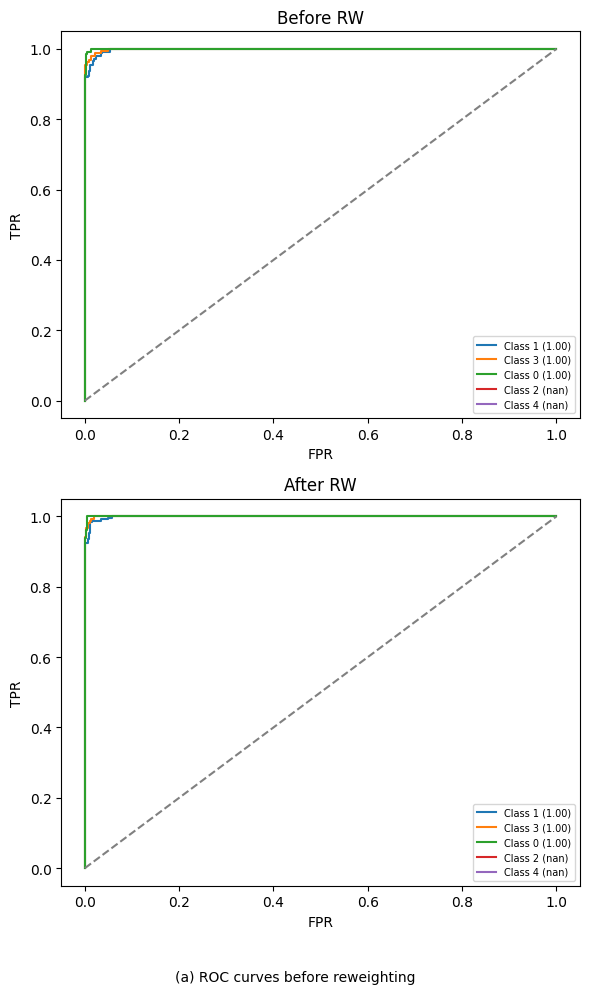

In [47]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(5,4))
# for cls, score in hardest_classes:
#     fpr, tpr, _ = roc_curve(y_true[:, cls], y_pred[:, cls])
# #     plt.plot(fpr, tpr, label=f'Class {cls} (AUC={score:.2f})')
#     plt.plot(fpr, tpr, label=f'Class {cls}')

# plt.plot([0,1], [0,1], linestyle='--', color='gray')
# plt.rcParams.update({
#     "font.size": 10,
#     "axes.titlesize": 14,
#     "axes.labelsize": 12,
#     "legend.fontsize": 10
# })

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")

# plt.title("ROC Curves for Top 5 Hardest Classes")
# plt.legend(loc="lower right")
# plt.grid(False)
# Save (EPS for paper)
# plt.savefig("P01_03_roc_classes_rgb.eps", format='eps', dpi=700, bbox_inches='tight')

# plt.show()

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# =========================
# COMPUTE AUC
# =========================
auc_scores = []
for c in range(NUM_CLASSES):
    fpr_b, tpr_b, _ = roc_curve(y_true[:, c], scores_before[:, c])
    auc_b = auc(fpr_b, tpr_b)
    auc_scores.append((c, auc_b))

# Sort → hardest classes
auc_scores_sorted = sorted(auc_scores, key=lambda x: x[1])
hardest_classes = auc_scores_sorted[:5]

print("\nTop 5 hardest classes:")
for cls, auc_b in hardest_classes:
    print(f"Class {cls}: AUC={auc_b:.3f}")

# =========================
# VERTICAL PLOT (UP & DOWN)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(6, 10))  # 2 rows, 1 column

# -------- BEFORE RW (Top) --------
for cls, _ in hardest_classes:
    fpr_b, tpr_b, _ = roc_curve(y_true[:, cls], scores_before[:, cls])
    auc_b = auc(fpr_b, tpr_b)
    axes[0].plot(fpr_b, tpr_b, label=f'Class {cls} ({auc_b:.2f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title("Before RW")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend(fontsize=7)
axes[0].grid(False)

# -------- AFTER RW (Bottom) --------
for cls, _ in hardest_classes:
    fpr_a, tpr_a, _ = roc_curve(y_true[:, cls], scores_after[:, cls])
    auc_a = auc(fpr_a, tpr_a)
    axes[1].plot(fpr_a, tpr_a, label=f'Class {cls} ({auc_a:.2f})')

axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title("After RW")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend(fontsize=7)
axes[1].grid(False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space at bottom for caption

# =========================
# SINGLE CAPTION BELOW BOTH
# =========================
fig.text(
    0.5, 0.01,
    "(a) ROC curves before reweighting",
    ha='center', va='bottom', fontsize=10
)

# =========================
# SAVE
# =========================
# plt.savefig("../Metrics/Charades/00N38_roc_vertical.eps",
#             format='eps', dpi=700, bbox_inches='tight')
plt.show()